In [68]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score
from sklearn.preprocessing import StandardScaler
import  matplotlib.pyplot as plt
data=load_breast_cancer()
x=data['data']
y=data['target']
train_x,test_x,train_y,test_y=train_test_split(x,y,random_state=50,test_size=0.6)

## Linear Regression

The r2_score of model: 0.758016984682059
The mean squared error of model: 0.05734900640037382


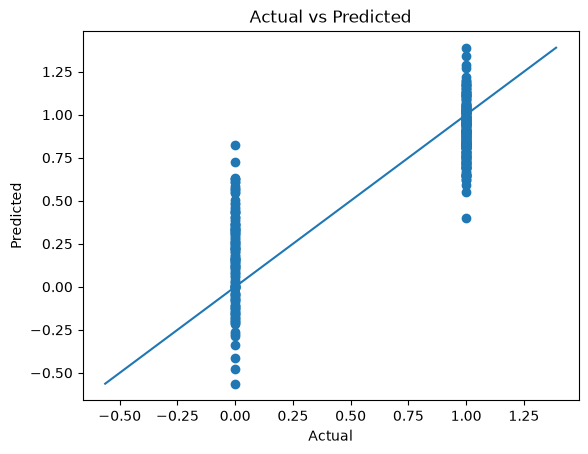

In [69]:
model=LinearRegression()
model.fit(x,y)
result=model.predict(test_x)
print(f"The r2_score of model: {r2_score(test_y,result)}")
print(f"The mean squared error of model: {mean_squared_error(test_y,result)}")
plt.scatter(test_y, result)
minimum = min(test_y.min(), result.min())
maximum = max(test_y.max(), result.max())
plt.plot([minimum, maximum], [minimum, maximum])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Logistic Regression Without Scaling

The score of the classification: 0.935672514619883
The accuracy of classification: 0.935672514619883


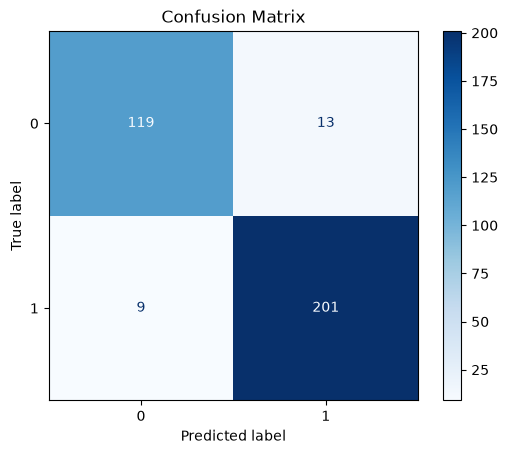

In [70]:
model=LogisticRegression(max_iter=10000)
model.fit(train_x,train_y)
result=model.predict(test_x)
score_without_scaling=model.score(test_x,test_y)
accuracy_without_scaling=accuracy_score(test_y,result)
print(f"The score of the classification: {score_without_scaling}")#for trained model
print(f"The accuracy of classification: {accuracy_without_scaling}")#for predicted data

cm=confusion_matrix(test_y,result)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

The score of the classification: 0.9649122807017544
The accuracy of classification: 0.9649122807017544
The difference between scaled and unscaled accuracy: 0.0292397660818714


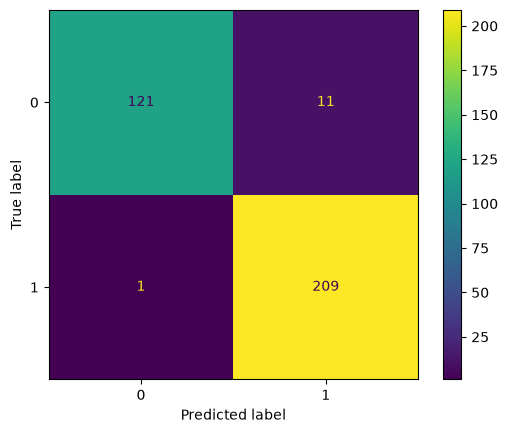

In [71]:
scaler=StandardScaler()
model=LogisticRegression()
train_x_scaled=scaler.fit_transform(train_x)
test_x_scaled=scaler.transform(test_x)
model.fit(train_x_scaled,train_y)
result=model.predict(test_x_scaled)
scaled_score=model.score(test_x_scaled,test_y)
scaled_accuracy=accuracy_score(test_y,result)
print(f"The score of the classification: {scaled_score}")#for trained model
print(f"The accuracy of classification: {scaled_accuracy}")#for predicted data

print(f"The difference between scaled and unscaled accuracy: {scaled_accuracy - accuracy_without_scaling}")

cm=confusion_matrix(test_y,result)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()